# 📊 Exploratory Data Analysis (EDA) — Dự Đoán Giá BĐS Hà Nội

Notebook này phân tích dữ liệu đã được làm sạch để:
1. **Chứng minh** tại sao cần tách 2 model (Chung cư vs Nhà đất)
2. Khám phá mối tương quan giữa các features và giá
3. Quyết định có cần `log(price)` khi train không

**Input:** `data/processed/cleaned_chung_cu.csv`, `cleaned_nha_dat.csv`, `cleaned_full_web.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ===== Style Setup =====
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#1a1d23',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
})
PALETTE = ['#00d4aa', '#ff6b6b']
sns.set_palette(PALETTE)

# ===== Load Data =====
df_cc = pd.read_csv('../data/processed/cleaned_chung_cu.csv')
df_nd = pd.read_csv('../data/processed/cleaned_nha_dat.csv')
df_full = pd.read_csv('../data/processed/cleaned_full_web.csv')

# Tạo cột loại BĐS đơn giản cho full dataset
df_full['loai_bds'] = df_full['property_type'].apply(
    lambda x: 'Chung cư' if 'chung cư' in str(x).lower() else 'Nhà đất'
)

print(f'Chung cư: {len(df_cc)} dòng × {len(df_cc.columns)} features')
print(f'Nhà đất:  {len(df_nd)} dòng × {len(df_nd.columns)} features')
print(f'Full:     {len(df_full)} dòng')

Chung cư: 5452 dòng × 13 features
Nhà đất:  6379 dòng × 15 features
Full:     11831 dòng


---
## 1️⃣ Boxplot Giá — Tại sao phải tách 2 Model?

Biểu đồ quan trọng nhất: So sánh phân bố giá giữa Chung cư và Nhà đất.  
Nếu 2 boxplot có **median, IQR và range khác biệt rõ rệt** → chứng minh đây là 2 bài toán hồi quy khác nhau.

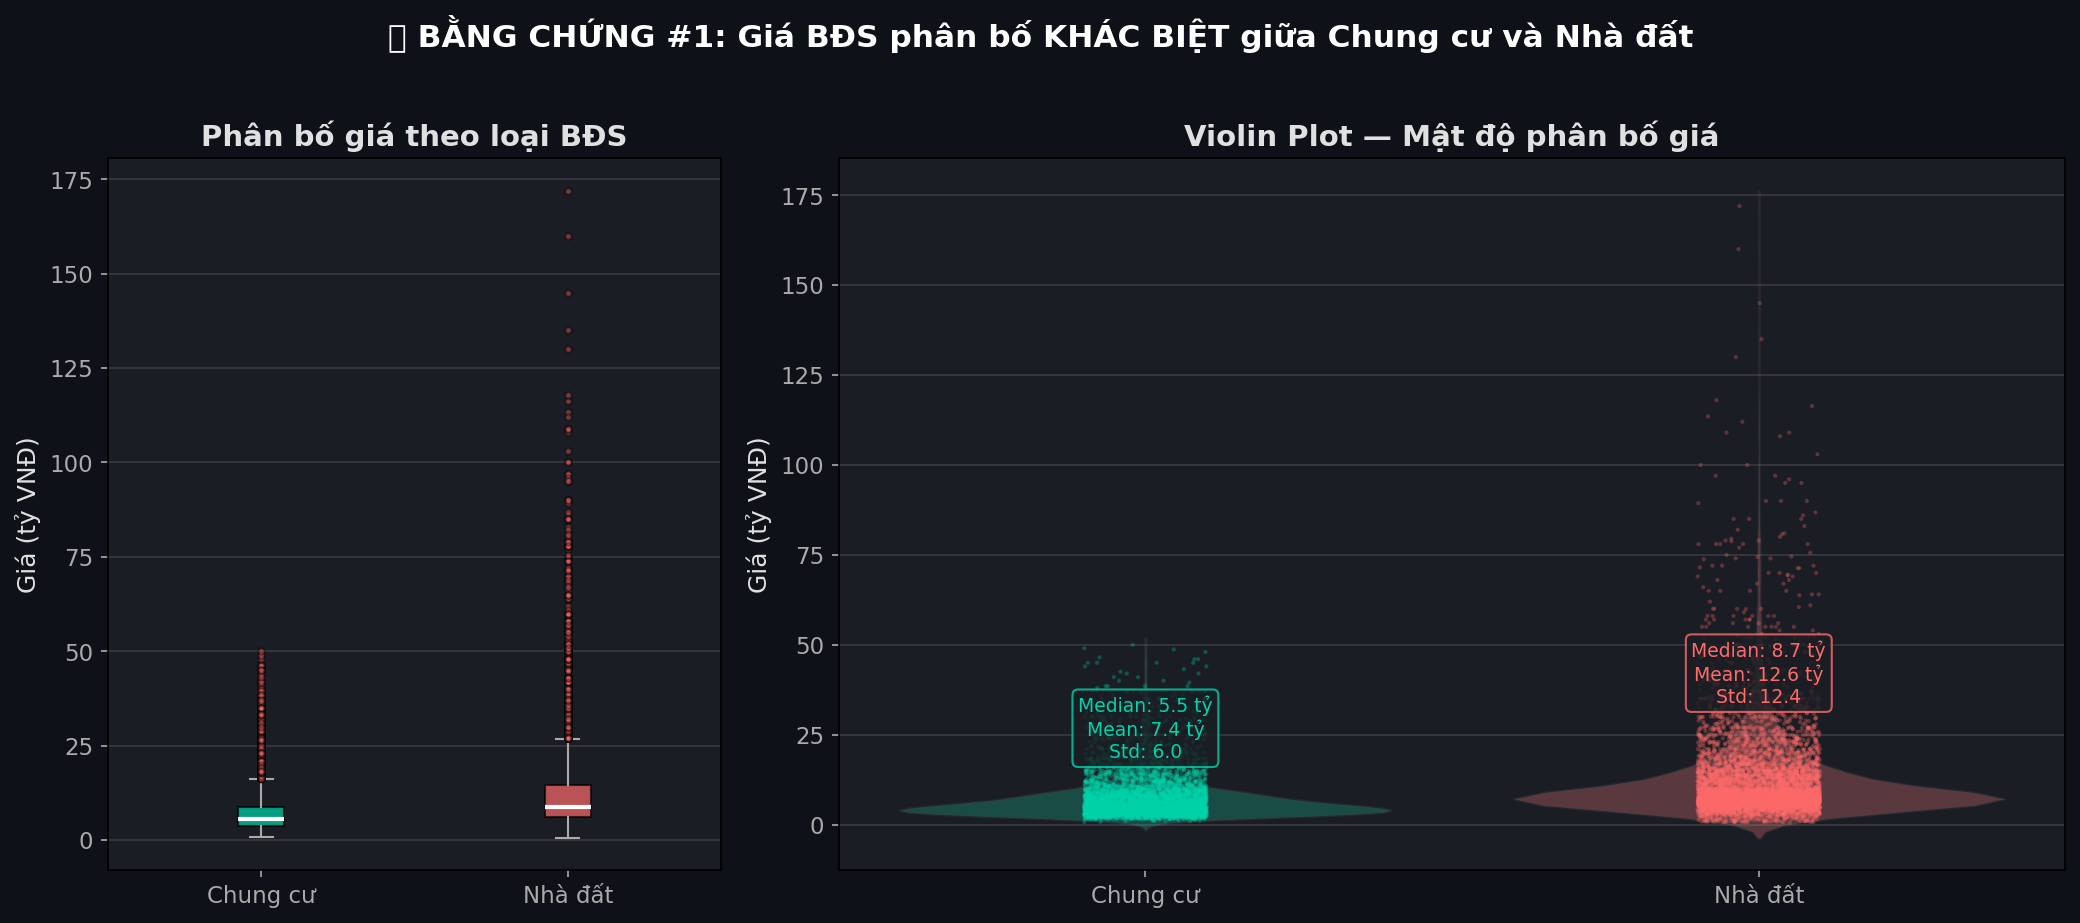

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2]})

# --- Left: Boxplot ---
bp = axes[0].boxplot(
    [df_cc['price_billion'], df_nd['price_billion']],
    labels=['Chung cư', 'Nhà đất'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#aaaaaa'),
    capprops=dict(color='#aaaaaa'),
    flierprops=dict(marker='o', markerfacecolor='#ff6b6b', markersize=3, alpha=0.4),
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel('Giá (tỷ VNĐ)')
axes[0].set_title('Phân bố giá theo loại BĐS')
axes[0].grid(axis='y', alpha=0.2)

# --- Right: Violin + Strip ---
sns.violinplot(data=df_full, x='loai_bds', y='price_billion', 
               palette=PALETTE, inner=None, alpha=0.3, ax=axes[1])
sns.stripplot(data=df_full, x='loai_bds', y='price_billion',
              palette=PALETTE, size=2, alpha=0.3, jitter=True, ax=axes[1])

axes[1].set_xlabel('')
axes[1].set_ylabel('Giá (tỷ VNĐ)')
axes[1].set_title('Violin Plot — Mật độ phân bố giá')
axes[1].grid(axis='y', alpha=0.2)

# --- Stats annotation ---
for i, (name, data) in enumerate([('CC', df_cc), ('NĐ', df_nd)]):
    stats_text = f"Median: {data['price_billion'].median():.1f} tỷ\nMean: {data['price_billion'].mean():.1f} tỷ\nStd: {data['price_billion'].std():.1f}"
    axes[1].annotate(stats_text, xy=(i, data['price_billion'].quantile(0.95)),
                     fontsize=9, color=PALETTE[i], ha='center',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1d23', edgecolor=PALETTE[i], alpha=0.8))

plt.suptitle('🏠 BẰNG CHỨNG #1: Giá BĐS phân bố KHÁC BIỆT giữa Chung cư và Nhà đất',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_01_boxplot_gia.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 2️⃣ Scatter Plot — Diện tích × Giá (hue = Loại BĐS)

Nếu 2 loại tạo thành **2 cluster riêng biệt** trên mặt phẳng (area, price) → 1 model duy nhất sẽ không fit được cả 2.

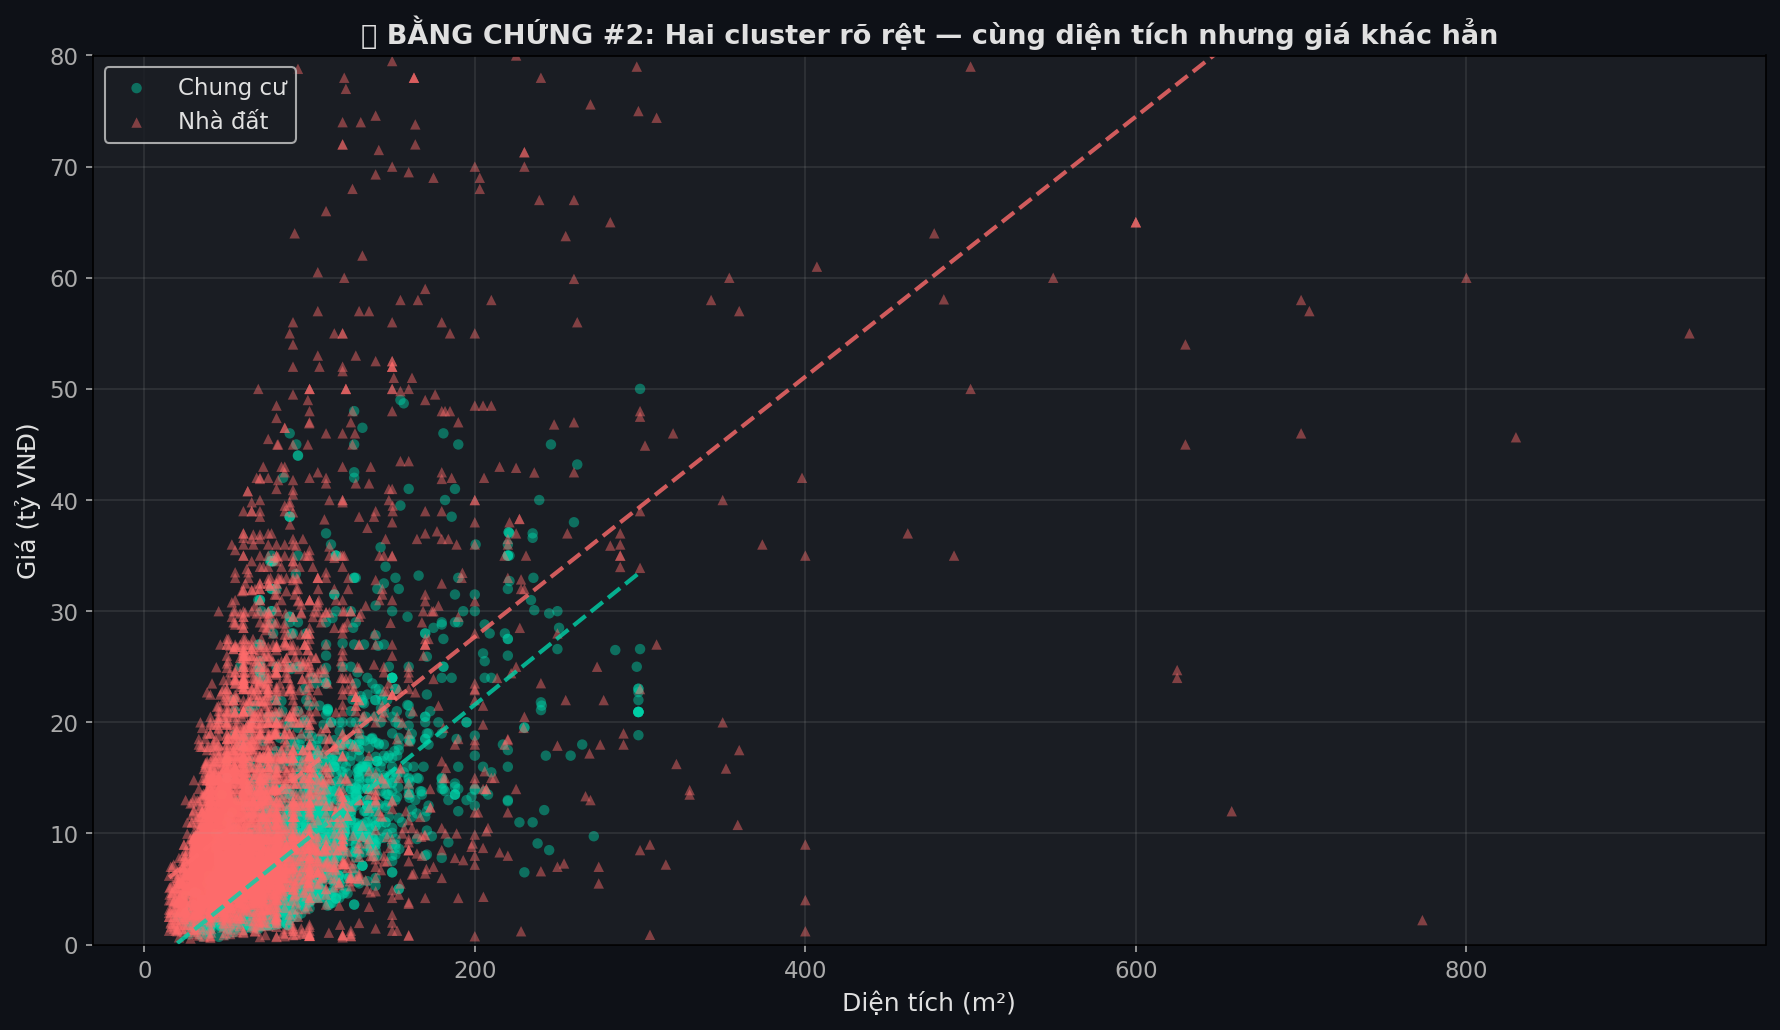

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))

for label, color, marker in [('Chung cư', PALETTE[0], 'o'), ('Nhà đất', PALETTE[1], '^')]:
    subset = df_full[df_full['loai_bds'] == label]
    ax.scatter(subset['area_m2'], subset['price_billion'],
               c=color, marker=marker, alpha=0.45, s=25, label=label, edgecolors='none')

# Trend lines
for label, color in [('Chung cư', PALETTE[0]), ('Nhà đất', PALETTE[1])]:
    subset = df_full[df_full['loai_bds'] == label]
    z = np.polyfit(subset['area_m2'], subset['price_billion'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['area_m2'].min(), subset['area_m2'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--', alpha=0.8)

ax.set_xlabel('Diện tích (m²)')
ax.set_ylabel('Giá (tỷ VNĐ)')
ax.set_ylim(0, 80)
ax.set_title('🏠 BẰNG CHỨNG #2: Hai cluster rõ rệt — cùng diện tích nhưng giá khác hẳn',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left', framealpha=0.8)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig('../data/processed/eda_02_scatter_area_price.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 3️⃣ Heatmap Tương Quan — Riêng biệt cho từng loại

So sánh 2 heatmap cạnh nhau để thấy:
- Chung cư: `area_m2` và `bedrooms_num` là features quan trọng nhất
- Nhà đất: `frontage_m`, `road_width_m`, `floors_num` có ảnh hưởng mà Chung cư không có

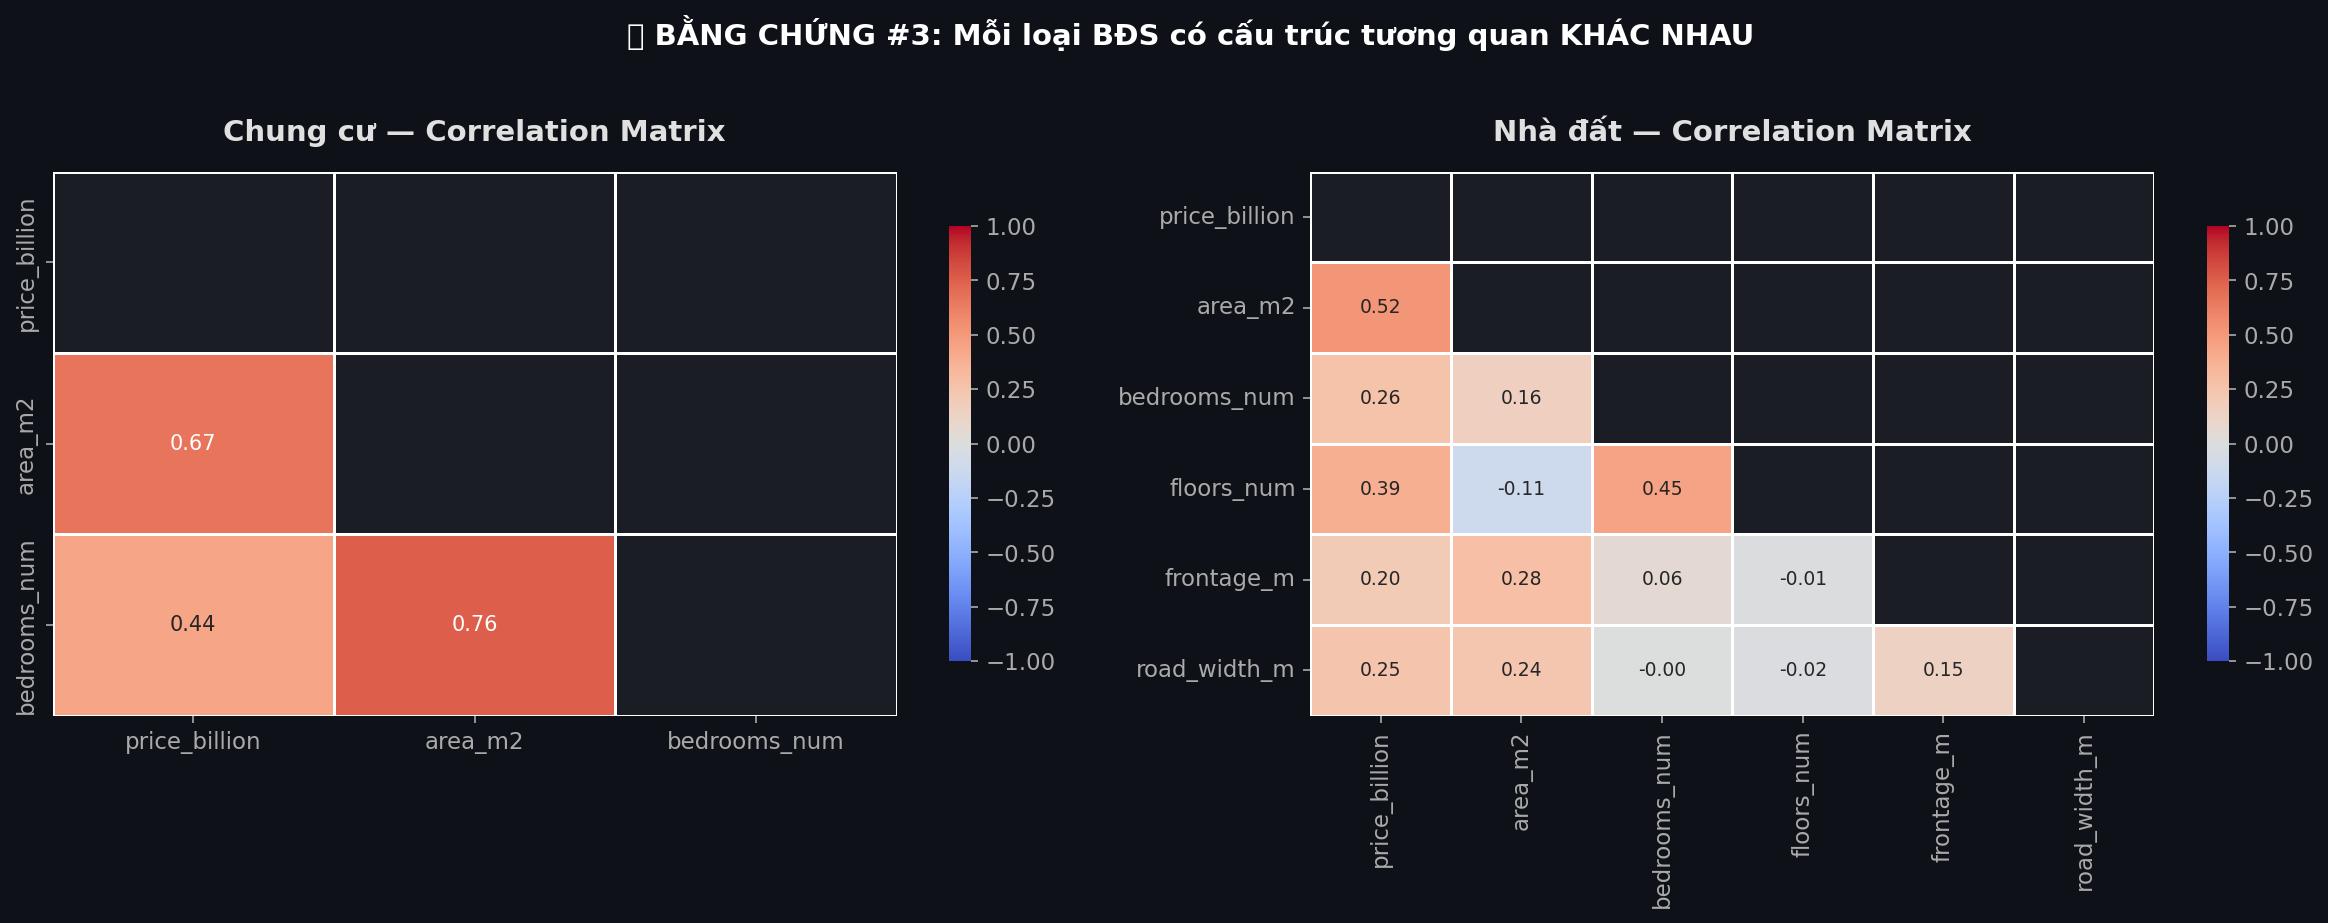

=== Top features ảnh hưởng giá (Chung cư) ===
area_m2         0.666642
bedrooms_num    0.443444

=== Top features ảnh hưởng giá (Nhà đất) ===
area_m2         0.519671
floors_num      0.386006
bedrooms_num    0.261147
road_width_m    0.251622
frontage_m      0.201513


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chung cư ---
numeric_cc = df_cc.select_dtypes(include=[np.number])
corr_cc = numeric_cc.corr()
mask_cc = np.triu(np.ones_like(corr_cc, dtype=bool))
sns.heatmap(corr_cc, mask=mask_cc, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8}, ax=axes[0])
axes[0].set_title('Chung cư — Correlation Matrix', pad=15)

# --- Nhà đất ---
numeric_nd = df_nd.select_dtypes(include=[np.number])
corr_nd = numeric_nd.corr()
mask_nd = np.triu(np.ones_like(corr_nd, dtype=bool))
sns.heatmap(corr_nd, mask=mask_nd, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title('Nhà đất — Correlation Matrix', pad=15)

plt.suptitle('🔥 BẰNG CHỨNG #3: Mỗi loại BĐS có cấu trúc tương quan KHÁC NHAU',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_03_heatmap_correlation.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()

# In top correlations with price
print('=== Top features ảnh hưởng giá (Chung cư) ===')
print(corr_cc['price_billion'].drop('price_billion').sort_values(ascending=False).to_string())
print('\n=== Top features ảnh hưởng giá (Nhà đất) ===')
print(corr_nd['price_billion'].drop('price_billion').sort_values(ascending=False).to_string())

---
## 4️⃣ Stacked Bar — Phân bố địa lý theo Quận

Cho thấy quận nào chủ yếu là Chung cư, quận nào chủ yếu là Nhà đất.

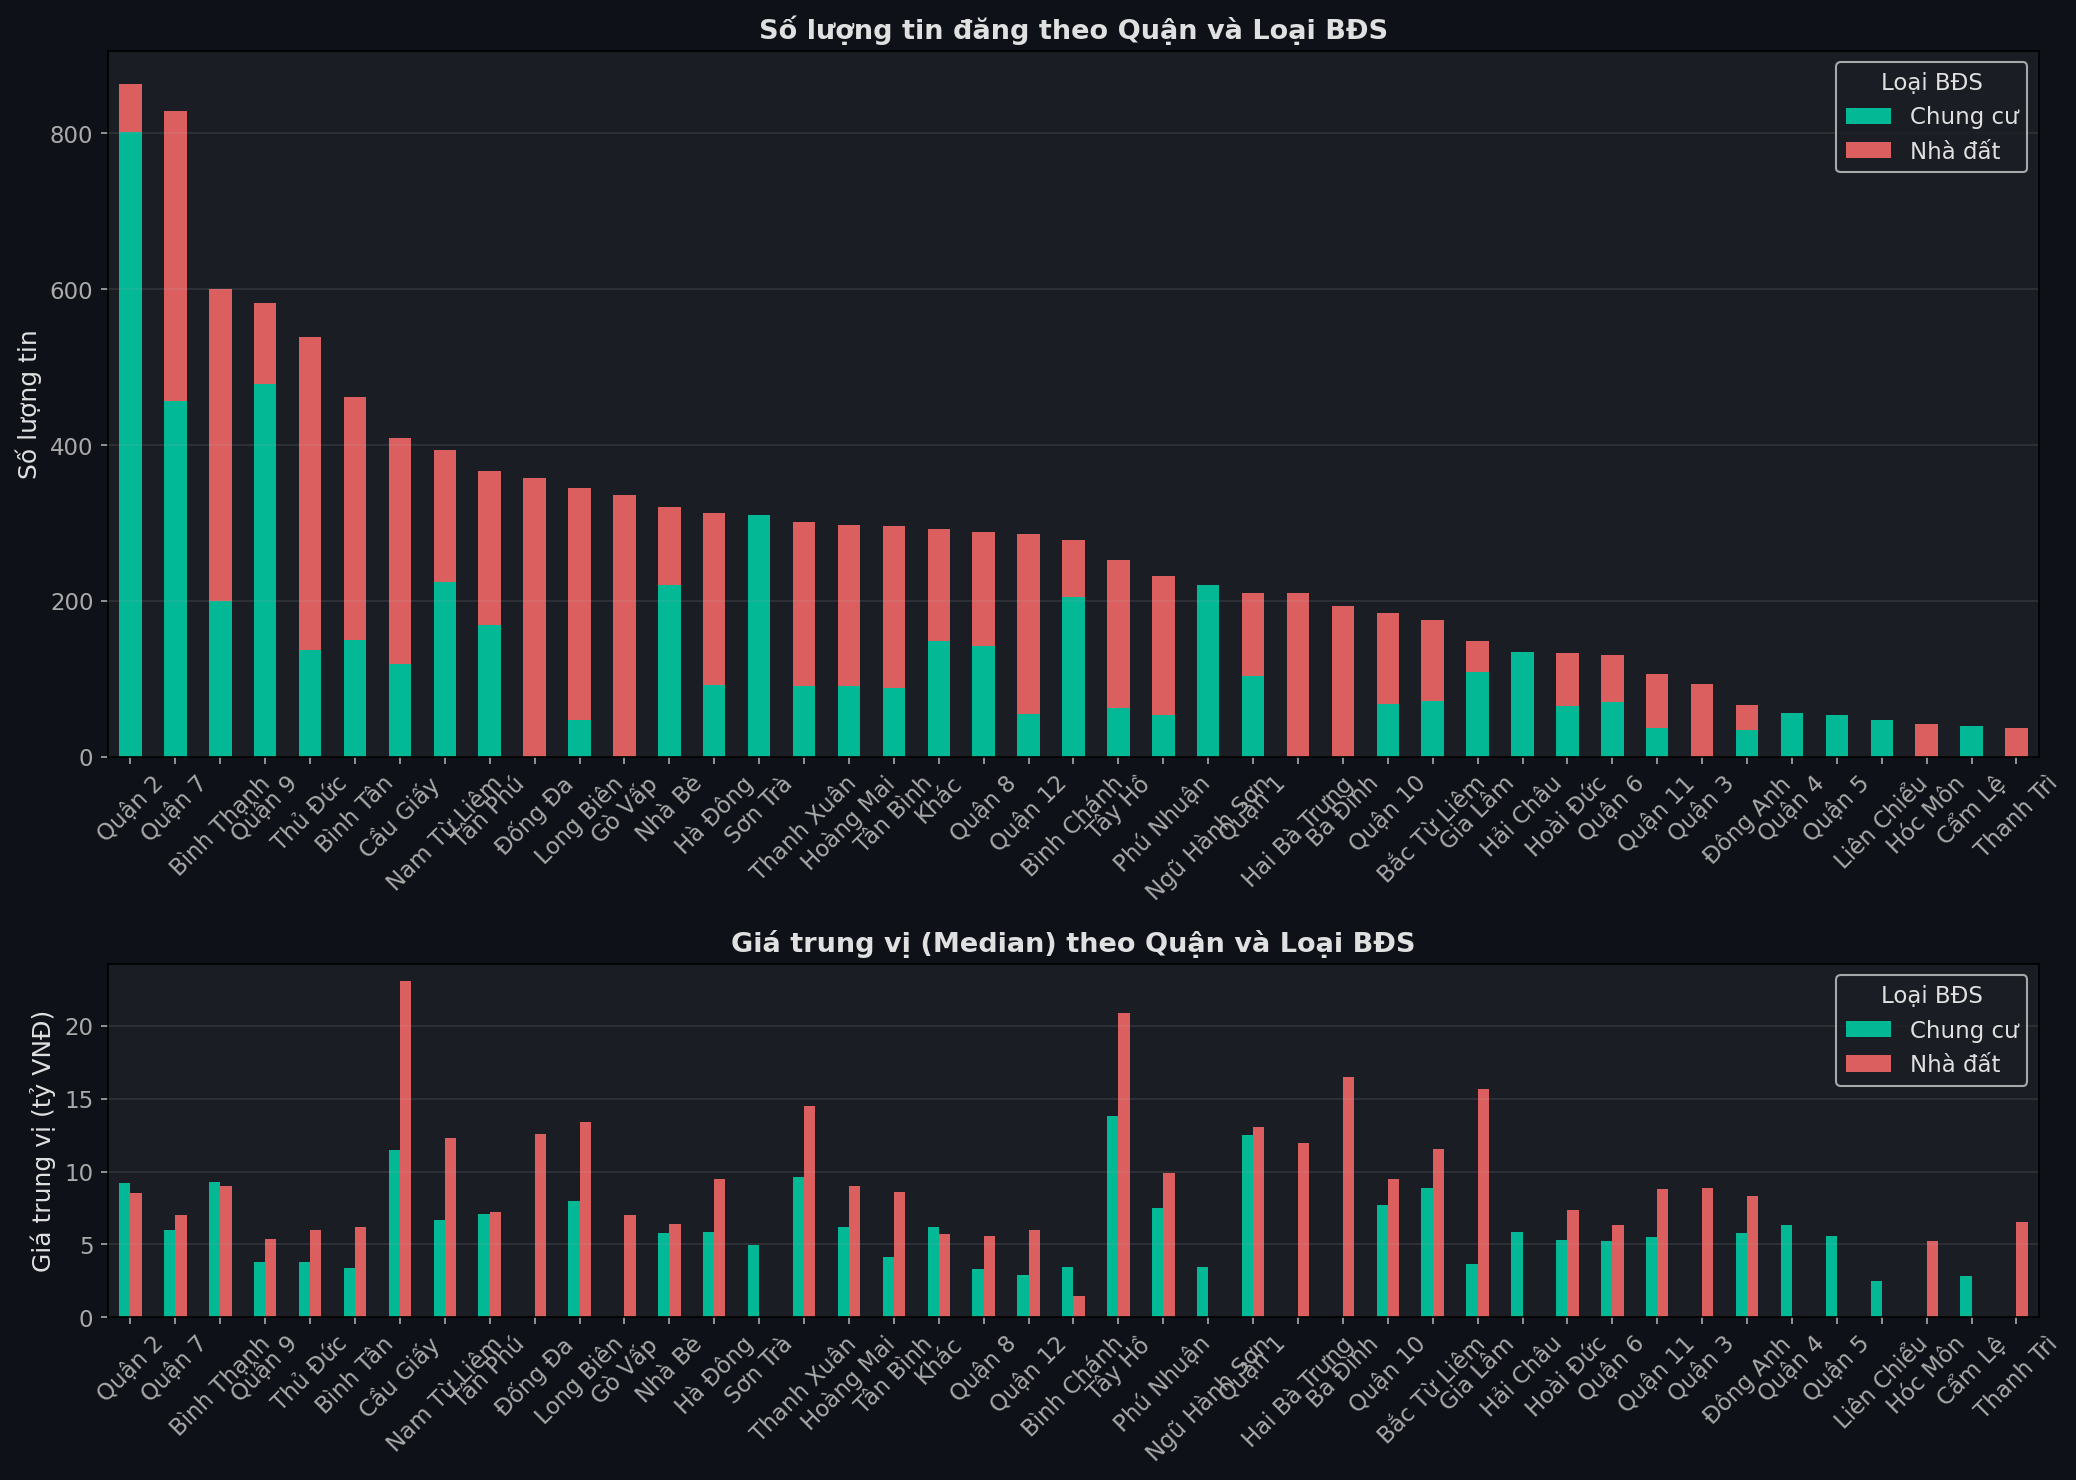

In [5]:
# Đếm số lượng theo quận và loại, sort theo tổng số tin
ct = pd.crosstab(df_full['district'], df_full['loai_bds'])
ct['total'] = ct.sum(axis=1)
ct = ct.sort_values('total', ascending=False).drop(columns='total')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Top: Stacked bar (count) ---
ct.plot(kind='bar', stacked=True, color=PALETTE, edgecolor='none', alpha=0.85, ax=axes[0])
axes[0].set_title('Số lượng tin đăng theo Quận và Loại BĐS', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Số lượng tin')
axes[0].legend(title='Loại BĐS', framealpha=0.8)
axes[0].grid(axis='y', alpha=0.15)
axes[0].tick_params(axis='x', rotation=45)

# --- Bottom: Giá trung vị theo quận ---
median_price = df_full.groupby(['district', 'loai_bds'])['price_billion'].median().unstack(fill_value=0)
median_price = median_price.reindex(ct.index)
median_price.plot(kind='bar', color=PALETTE, edgecolor='none', alpha=0.85, ax=axes[1])
axes[1].set_title('Giá trung vị (Median) theo Quận và Loại BĐS', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Giá trung vị (tỷ VNĐ)')
axes[1].legend(title='Loại BĐS', framealpha=0.8)
axes[1].grid(axis='y', alpha=0.15)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/eda_04_stacked_bar_district.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 5️⃣ Histogram Phân Phối Giá — Kiểm tra Skewness

Nếu phân phối **lệch phải mạnh (right-skewed)** → nên dùng `log(price)` khi train model để cải thiện hiệu suất Linear Regression.

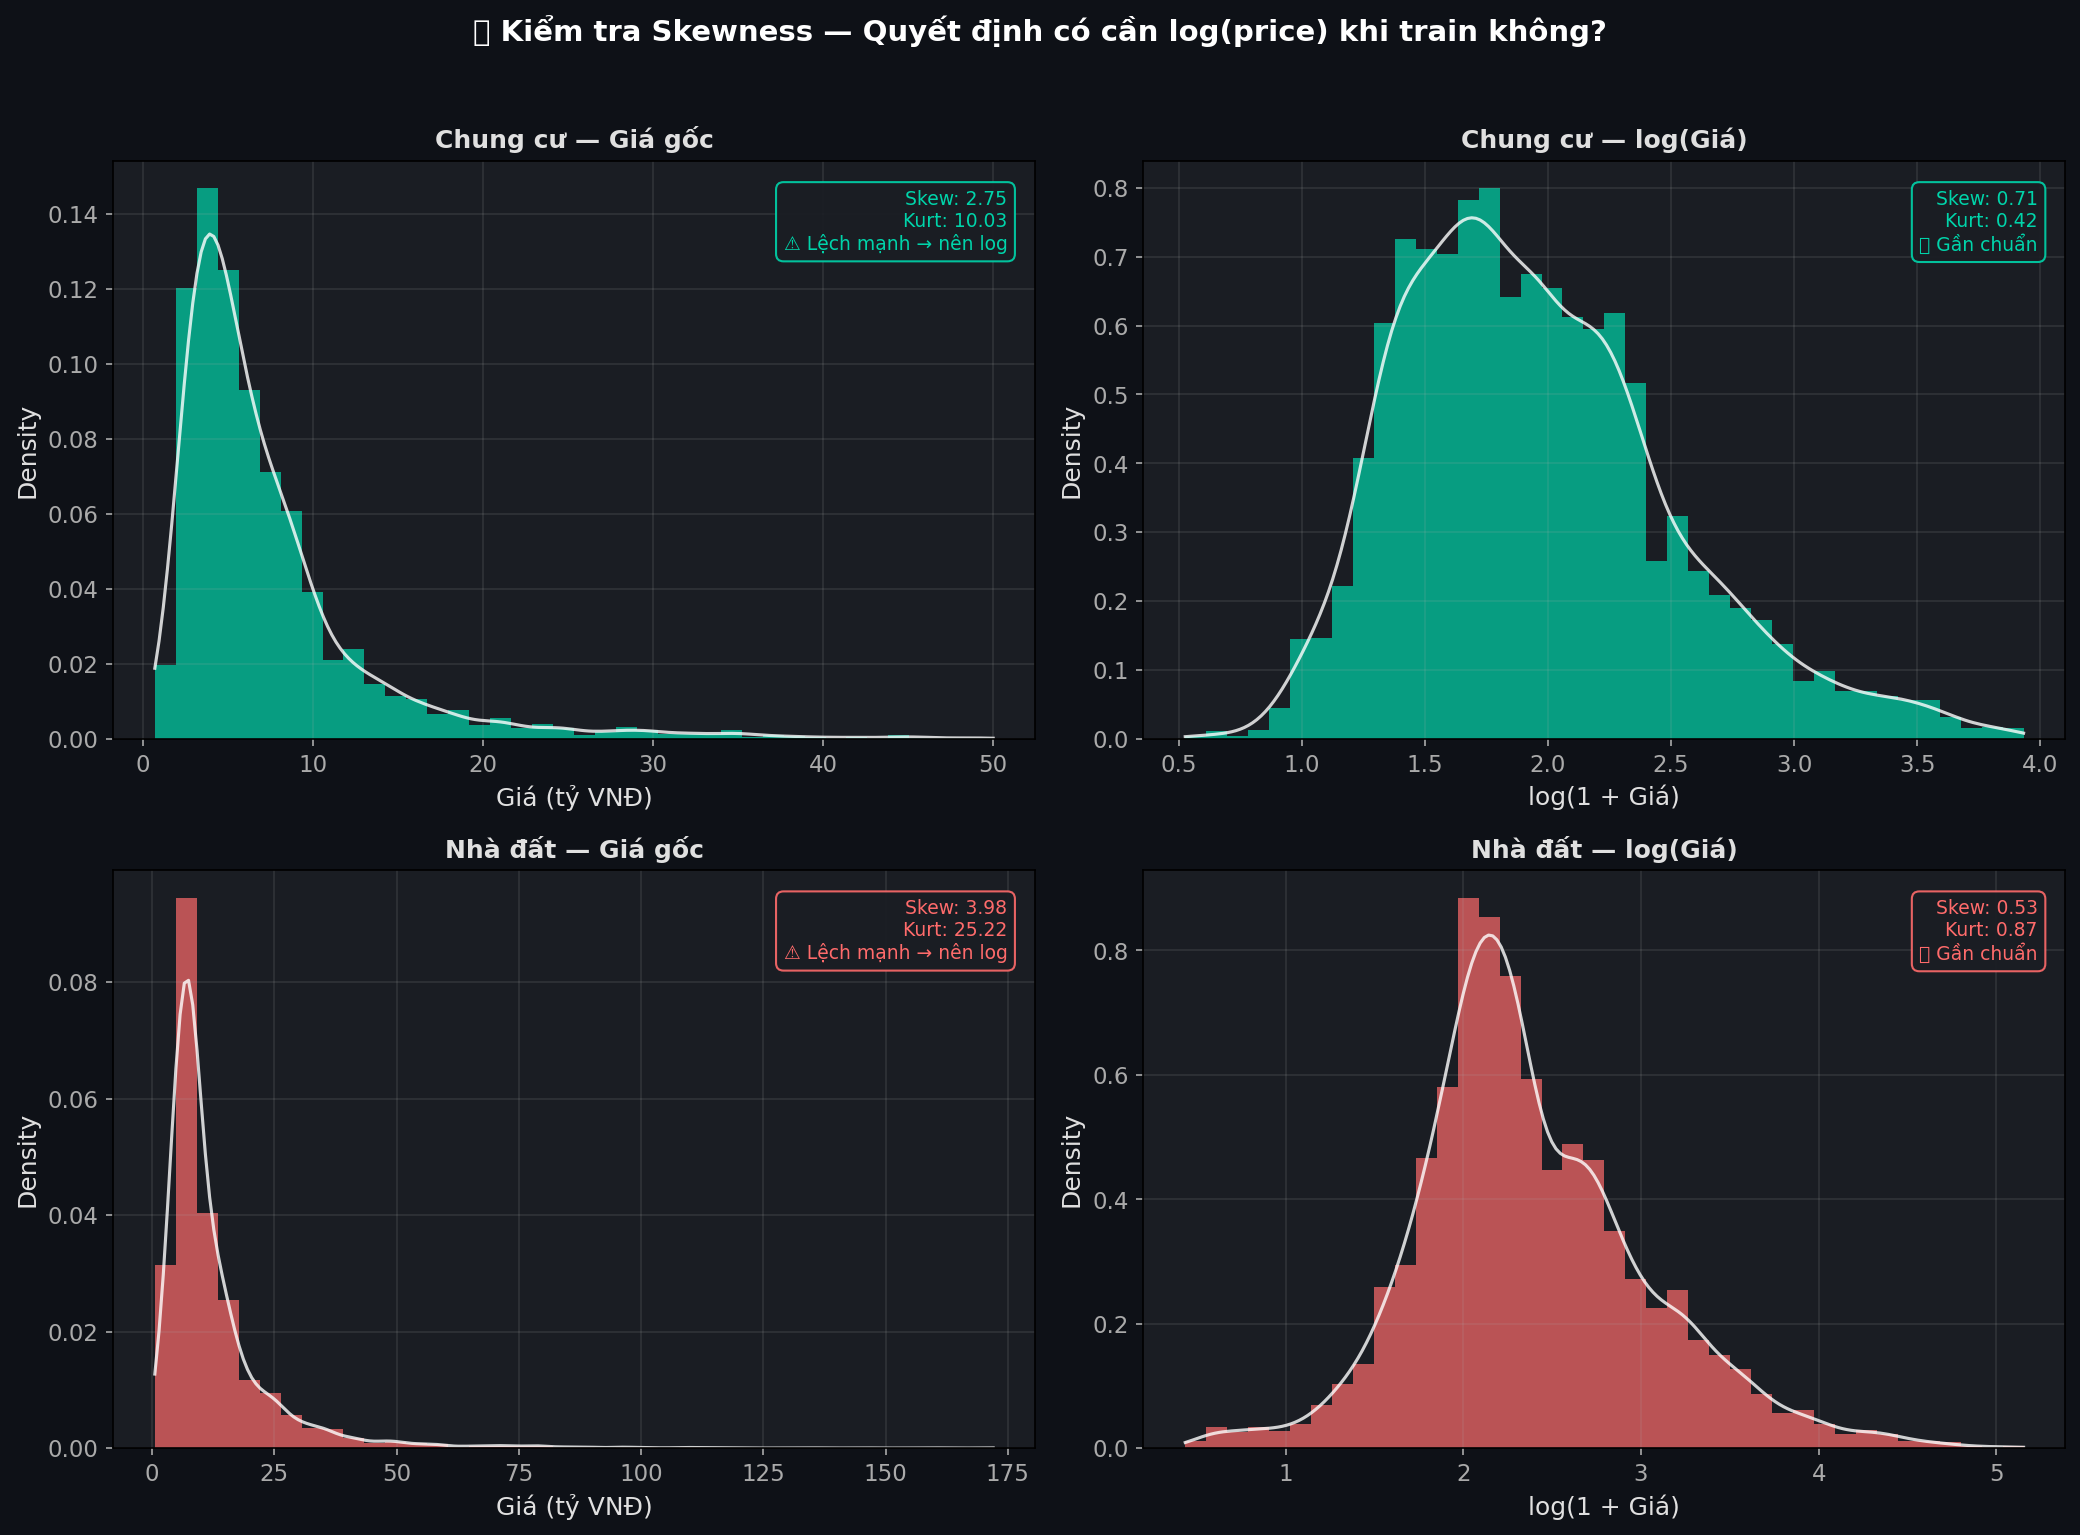

KẾT LUẬN:
  Chung cư: Skew gốc = 2.75, Skew sau log = 0.71
    → NÊN dùng log(price) khi train Chung cư
  Nhà đất: Skew gốc = 3.98, Skew sau log = 0.53
    → NÊN dùng log(price) khi train Nhà đất


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/tangoctai/Library/Python/3.9/lib/python/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.resu

In [6]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Chung cư — Giá gốc', df_cc['price_billion'], PALETTE[0], axes[0, 0]),
    ('Chung cư — log(Giá)', np.log1p(df_cc['price_billion']), PALETTE[0], axes[0, 1]),
    ('Nhà đất — Giá gốc', df_nd['price_billion'], PALETTE[1], axes[1, 0]),
    ('Nhà đất — log(Giá)', np.log1p(df_nd['price_billion']), PALETTE[1], axes[1, 1]),
]

for title, data, color, ax in datasets:
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='none', density=True)
    
    # KDE overlay
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color='white', linewidth=1.5, alpha=0.8)
    
    skew = data.skew()
    kurt = data.kurtosis()
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Density')
    ax.grid(alpha=0.15)
    
    verdict = '✅ Gần chuẩn' if abs(skew) < 1 else '⚠️ Lệch mạnh → nên log'
    stats_text = f'Skew: {skew:.2f}\nKurt: {kurt:.2f}\n{verdict}'
    ax.annotate(stats_text, xy=(0.97, 0.95), xycoords='axes fraction',
                fontsize=9, ha='right', va='top', color=color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1d23', edgecolor=color, alpha=0.9))

axes[0, 0].set_xlabel('Giá (tỷ VNĐ)')
axes[0, 1].set_xlabel('log(1 + Giá)')
axes[1, 0].set_xlabel('Giá (tỷ VNĐ)')
axes[1, 1].set_xlabel('log(1 + Giá)')

plt.suptitle('📈 Kiểm tra Skewness — Quyết định có cần log(price) khi train không?',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_05_histogram_skewness.png', bbox_inches='tight', facecolor='#0e1117')
plt.show()

# Kết luận
print('='*50)
print('KẾT LUẬN:')
for name, data in [('Chung cư', df_cc['price_billion']), ('Nhà đất', df_nd['price_billion'])]:
    skew_orig = data.skew()
    skew_log = np.log1p(data).skew()
    print(f'  {name}: Skew gốc = {skew_orig:.2f}, Skew sau log = {skew_log:.2f}')
    if abs(skew_orig) > 1:
        print(f'    → NÊN dùng log(price) khi train {name}')
    else:
        print(f'    → Có thể dùng giá gốc, log chỉ cải thiện nhẹ')

---
## 📝 Tổng kết EDA

| # | Phát hiện | Ý nghĩa cho Model |
|---|---|---|
| 1 | Giá Chung cư và Nhà đất phân bố KHÁC NHAU | Cần tách 2 model riêng biệt |
| 2 | 2 cluster rõ rệt trên scatter plot | 1 model không thể fit cả 2 |
| 3 | Heatmap cho thấy features quan trọng khác nhau | Feature set khác nhau cho mỗi model |
| 4 | Phân bố địa lý không đều | Cần gom quận hiếm vào 'Khác' (đã làm) |
| 5 | Nếu skew > 1 → dùng log(price) khi train | Cải thiện Linear Regression đáng kể |